# Analytic Method: CS-01 TAS

**Purpose**: solve the Tele Assistance System as an open Jackson queueing network in closed form (M/M/c/K per node) across the full adaptation axis and check it against the Camara 2023 R1 / R2 targets.

**Inputs**: `data/config/profile/{dflt,opti}.json` (PACS-style Variable dicts) and `data/reference/baseline.json` (R1 / R2 thresholds).

**Outputs**:
- `data/results/analytic/<adaptation>/<profile>.json` - per-run metrics (nodes + network + routing + lambda_z).
- `data/results/analytic/<adaptation>/requirements.json` - R1 / R2 verdicts.
- `data/img/analytic/<adaptation>/*.png` - topology, heatmap, bars, delta figures.

**Equivalent CLI** (reproduces the four runs written by this notebook):
```bash
python -m src.methods.analytic --adaptation baseline
python -m src.methods.analytic --adaptation s1
python -m src.methods.analytic --adaptation s2
python -m src.methods.analytic --adaptation aggregate
```

This notebook is thin: all logic lives in `src.methods.analytic` and `src.view.qn_diagram`. The cells below just orchestrate, display, and save figures.

In [1]:
%matplotlib inline
from pathlib import Path

import pandas as pd

from src.methods.analytic import run
from src.view import (
    plot_qn_topology,
    plot_node_heatmap,
    plot_node_diffmap,
    plot_arch_bars,
    plot_arch_delta,
)

IMG_ROOT = Path("data/img/analytic")
ADAPTATIONS = ["baseline", "s1", "s2", "aggregate"]

# Human-readable scenario labels for plot titles / legends.
DISPLAY = {
    "baseline": "No Adaptation",
    "s1": "S1: Retry",
    "s2": "S2: Select-Reliable",
    "aggregate": "S1 & S2",
}

## 1. Solve every adaptation

`run(adp=a, wrt=True)` loads the resolved `NetCfg`, solves the Jackson network, writes the per-run envelope under `data/results/analytic/<adaptation>/`, and returns the per-node + aggregate DataFrames plus the R1 / R2 verdict.

In [2]:
results = {a: run(adp=a, wrt=True) for a in ADAPTATIONS}

# unpack the per-adaptation pieces used in every later cell
cfgs = {a: results[a]["config"] for a in ADAPTATIONS}
nodes = {a: results[a]["nodes"] for a in ADAPTATIONS}
nets = {a: results[a]["network"] for a in ADAPTATIONS}
reqs = {a: results[a]["requirements"] for a in ADAPTATIONS}

print(f"Solved {len(results)} adaptations; wrote JSONs under data/results/analytic/")

Solved 4 adaptations; wrote JSONs under data/results/analytic/


## 2. Network-wide summary + verdict

One row per adaptation: headline metrics (response time, utilisation, queue length) and the R1 / R2 pass flags.

In [3]:
rows = []
for a in ADAPTATIONS:
    n = nets[a].iloc[0]
    r = reqs[a]
    rows.append({
        "adaptation": a,
        "profile": cfgs[a].profile,
        r"$\mathbf{\overline{W}_{TAS}}$ [ms]": n["W_net"] * 1000,
        r"$\mathbf{\overline{\rho}_{TAS}}$": n["avg_rho"],
        r"$\mathbf{\rho_{TAS,\,Max}}$": n["max_rho"],
        r"$\mathbf{\overline{L}_{TAS}}$": n["L_net"],
        "R1": "PASS" if r["R1"]["pass"] else "FAIL",
        "R2": "PASS" if r["R2"]["pass"] else "FAIL",
    })
summary = pd.DataFrame(rows).set_index("adaptation")
summary.round(4)

,profile,$\mathbf{\overline{W}_{TAS}}$ [ms],$\mathbf{\overline{\rho}_{TAS}}$,"$\mathbf{\rho_{TAS,\,Max}}$",$\mathbf{\overline{L}_{TAS}}$,R1,R2
adaptation,,,,,,,
baseline,dflt,3.6017,0.3077,0.6942,7.3783,PASS,PASS
s1,opti,3.4063,0.3093,0.6052,7.1159,PASS,PASS
s2,opti,3.4425,0.3031,0.6900,6.9568,PASS,PASS
aggregate,opti,3.4478,0.3050,0.6876,7.0176,PASS,PASS


## 3. Per-node snapshot (baseline)

The reference configuration before any adaptation kicks in. `rho = lambda / (c * mu)`; `W`, `Wq` are in seconds; `L`, `Lq` are mean request counts.

In [4]:
nodes["baseline"][[
    "key", "name", "type", "lambda", "mu", "c", "K",
    "rho", "L", "W",
]].round(4)

,key,name,type,lambda,mu,c,K,rho,L,W
0,TAS_{1},TAS composite stage 1 (dispatch),M/M/s/K,345.0000,700.0,1,10,0.4929,0.9672,0.0028
1,TAS_{2},TAS composite stage 2 (medical dispatch),M/M/s/K,258.7500,700.0,1,10,0.3696,0.5862,0.0023
2,TAS_{3},TAS composite stage 3 (alarm dispatch),M/M/s/K,174.2250,700.0,1,10,0.2489,0.3314,0.0019
3,MAS_{1},Medical Analysis Service 1,M/M/s/K,97.0312,180.0,1,10,0.5391,1.1572,0.0119
4,MAS_{2},Medical Analysis Service 2,M/M/s/K,94.5968,530.0,1,10,0.1785,0.2173,0.0023
5,MAS_{3},Medical Analysis Service 3,M/M/s/K,104.1311,150.0,1,10,0.6942,2.0680,0.0200
6,AS_{1},Alarm Service 1,M/M/s/K,64.6003,700.0,1,10,0.0923,0.1017,0.0016
7,AS_{2},Alarm Service 2,M/M/s/K,61.7047,410.0,1,10,0.1505,0.1772,0.0029
8,AS_{3},Alarm Service 3,M/M/s/K,70.1149,1580.0,1,10,0.0444,0.0464,0.0007
9,TAS_{4},TAS composite stage 4 (drug dispatch),M/M/s/K,258.7500,700.0,1,10,0.3696,0.5862,0.0023


## 4. Queue-network topology (architecture view)

Nodes are coloured by `rho` (cool = low, warm = high). Edge labels show routing probabilities.

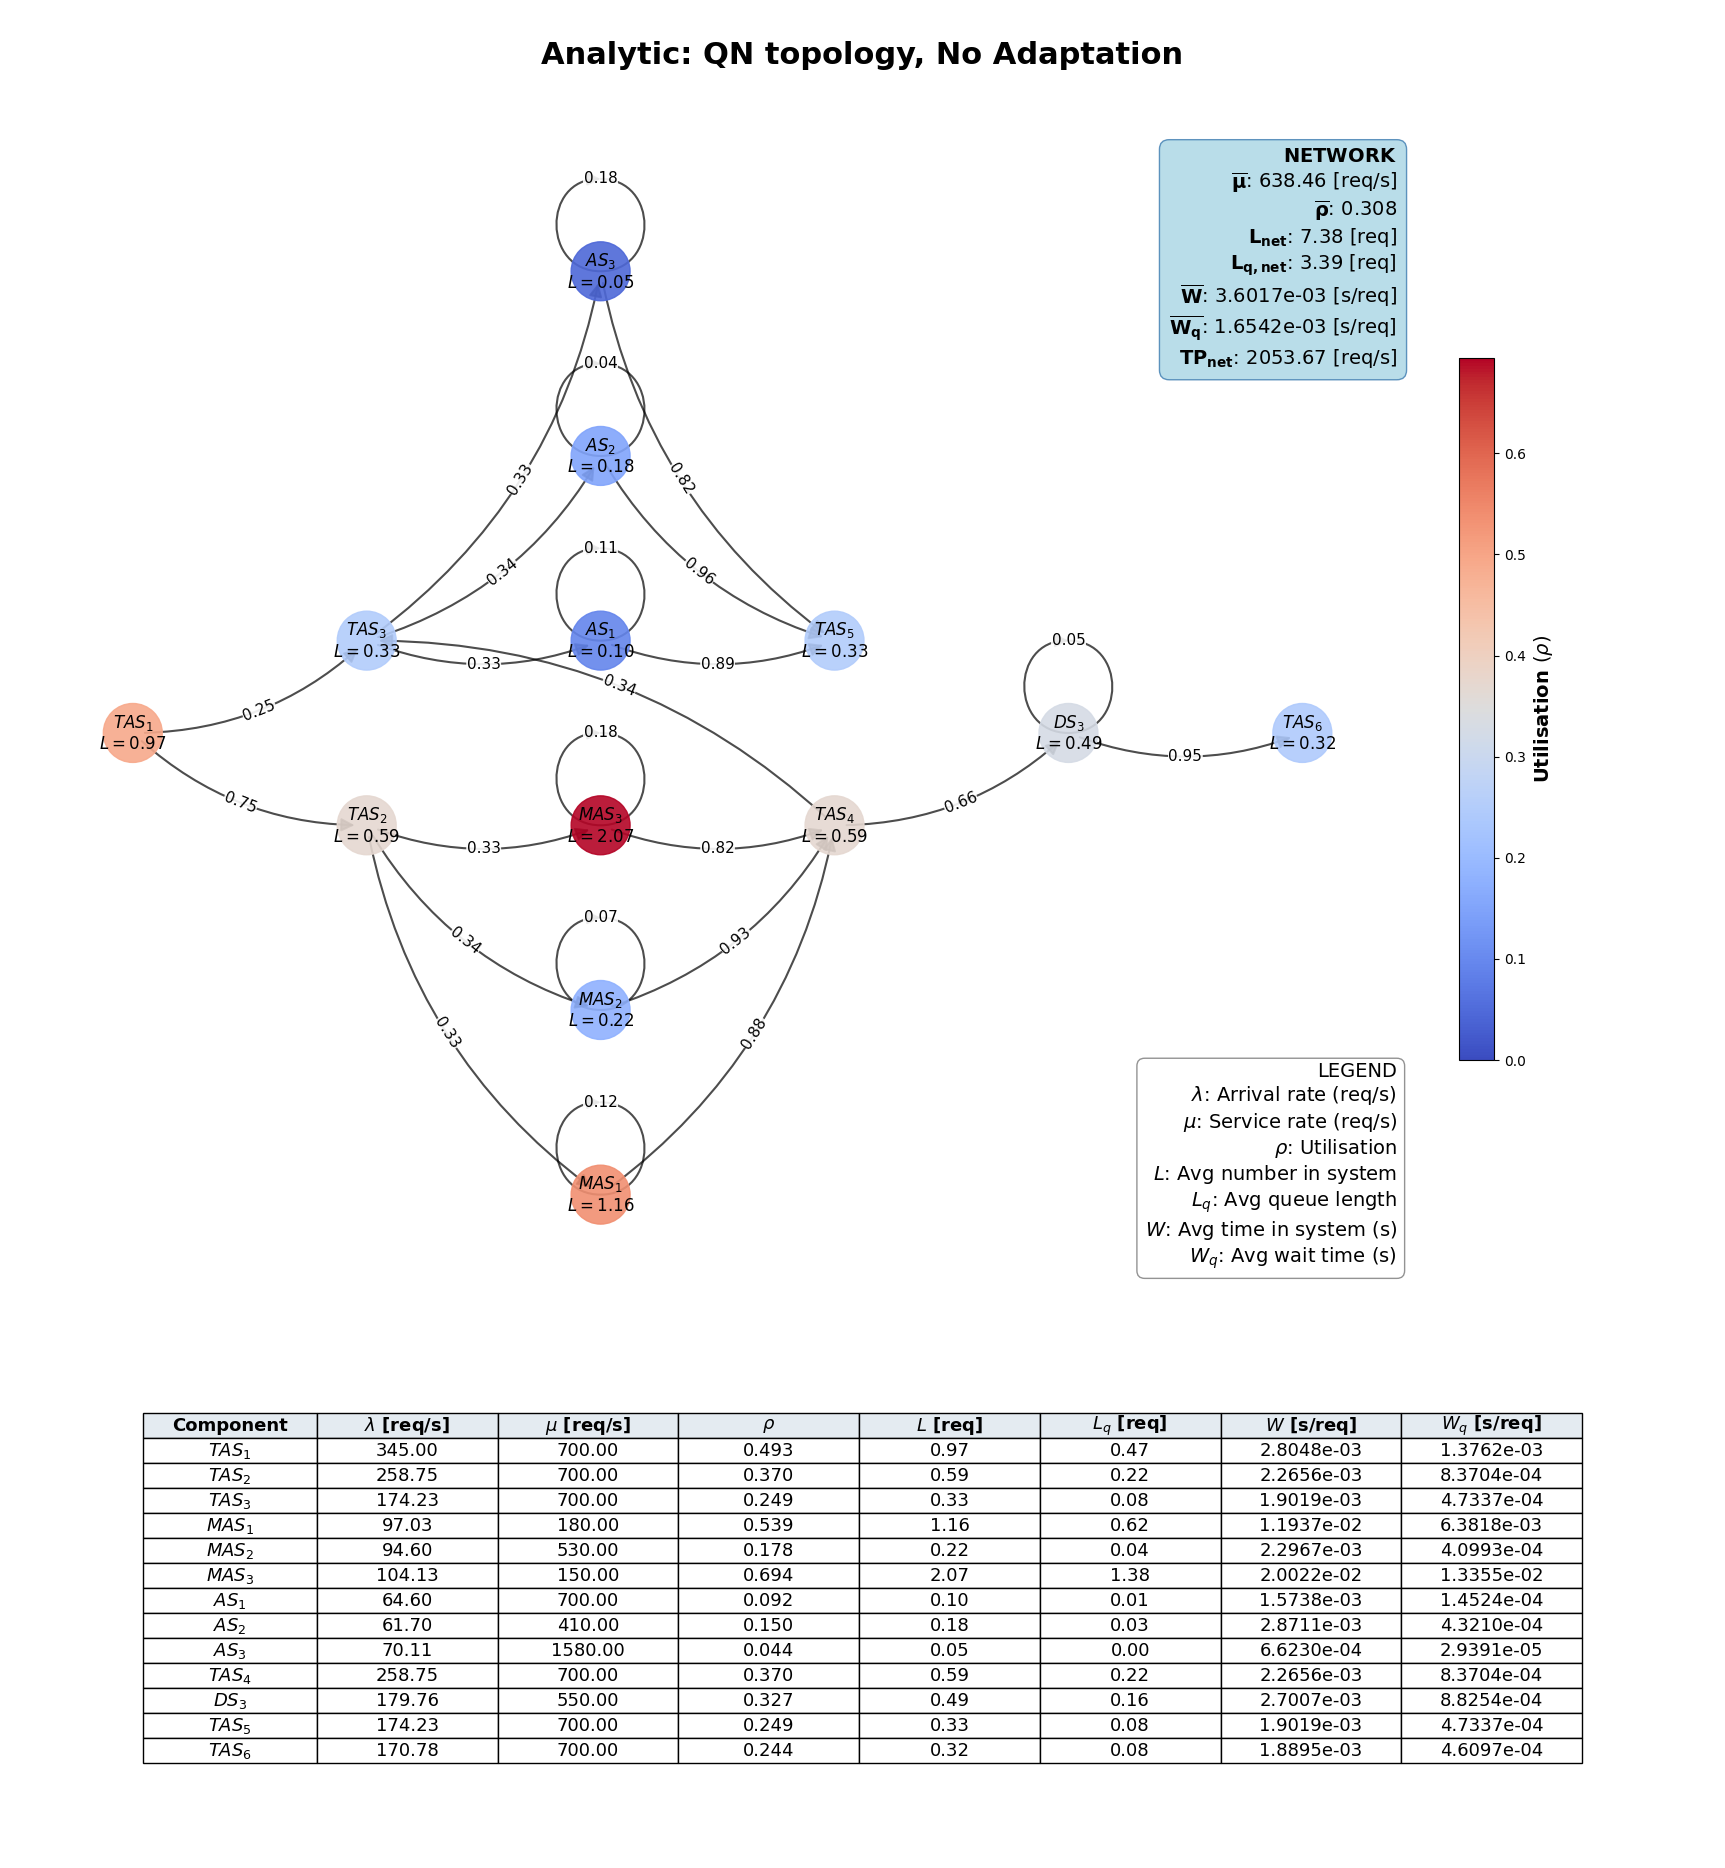

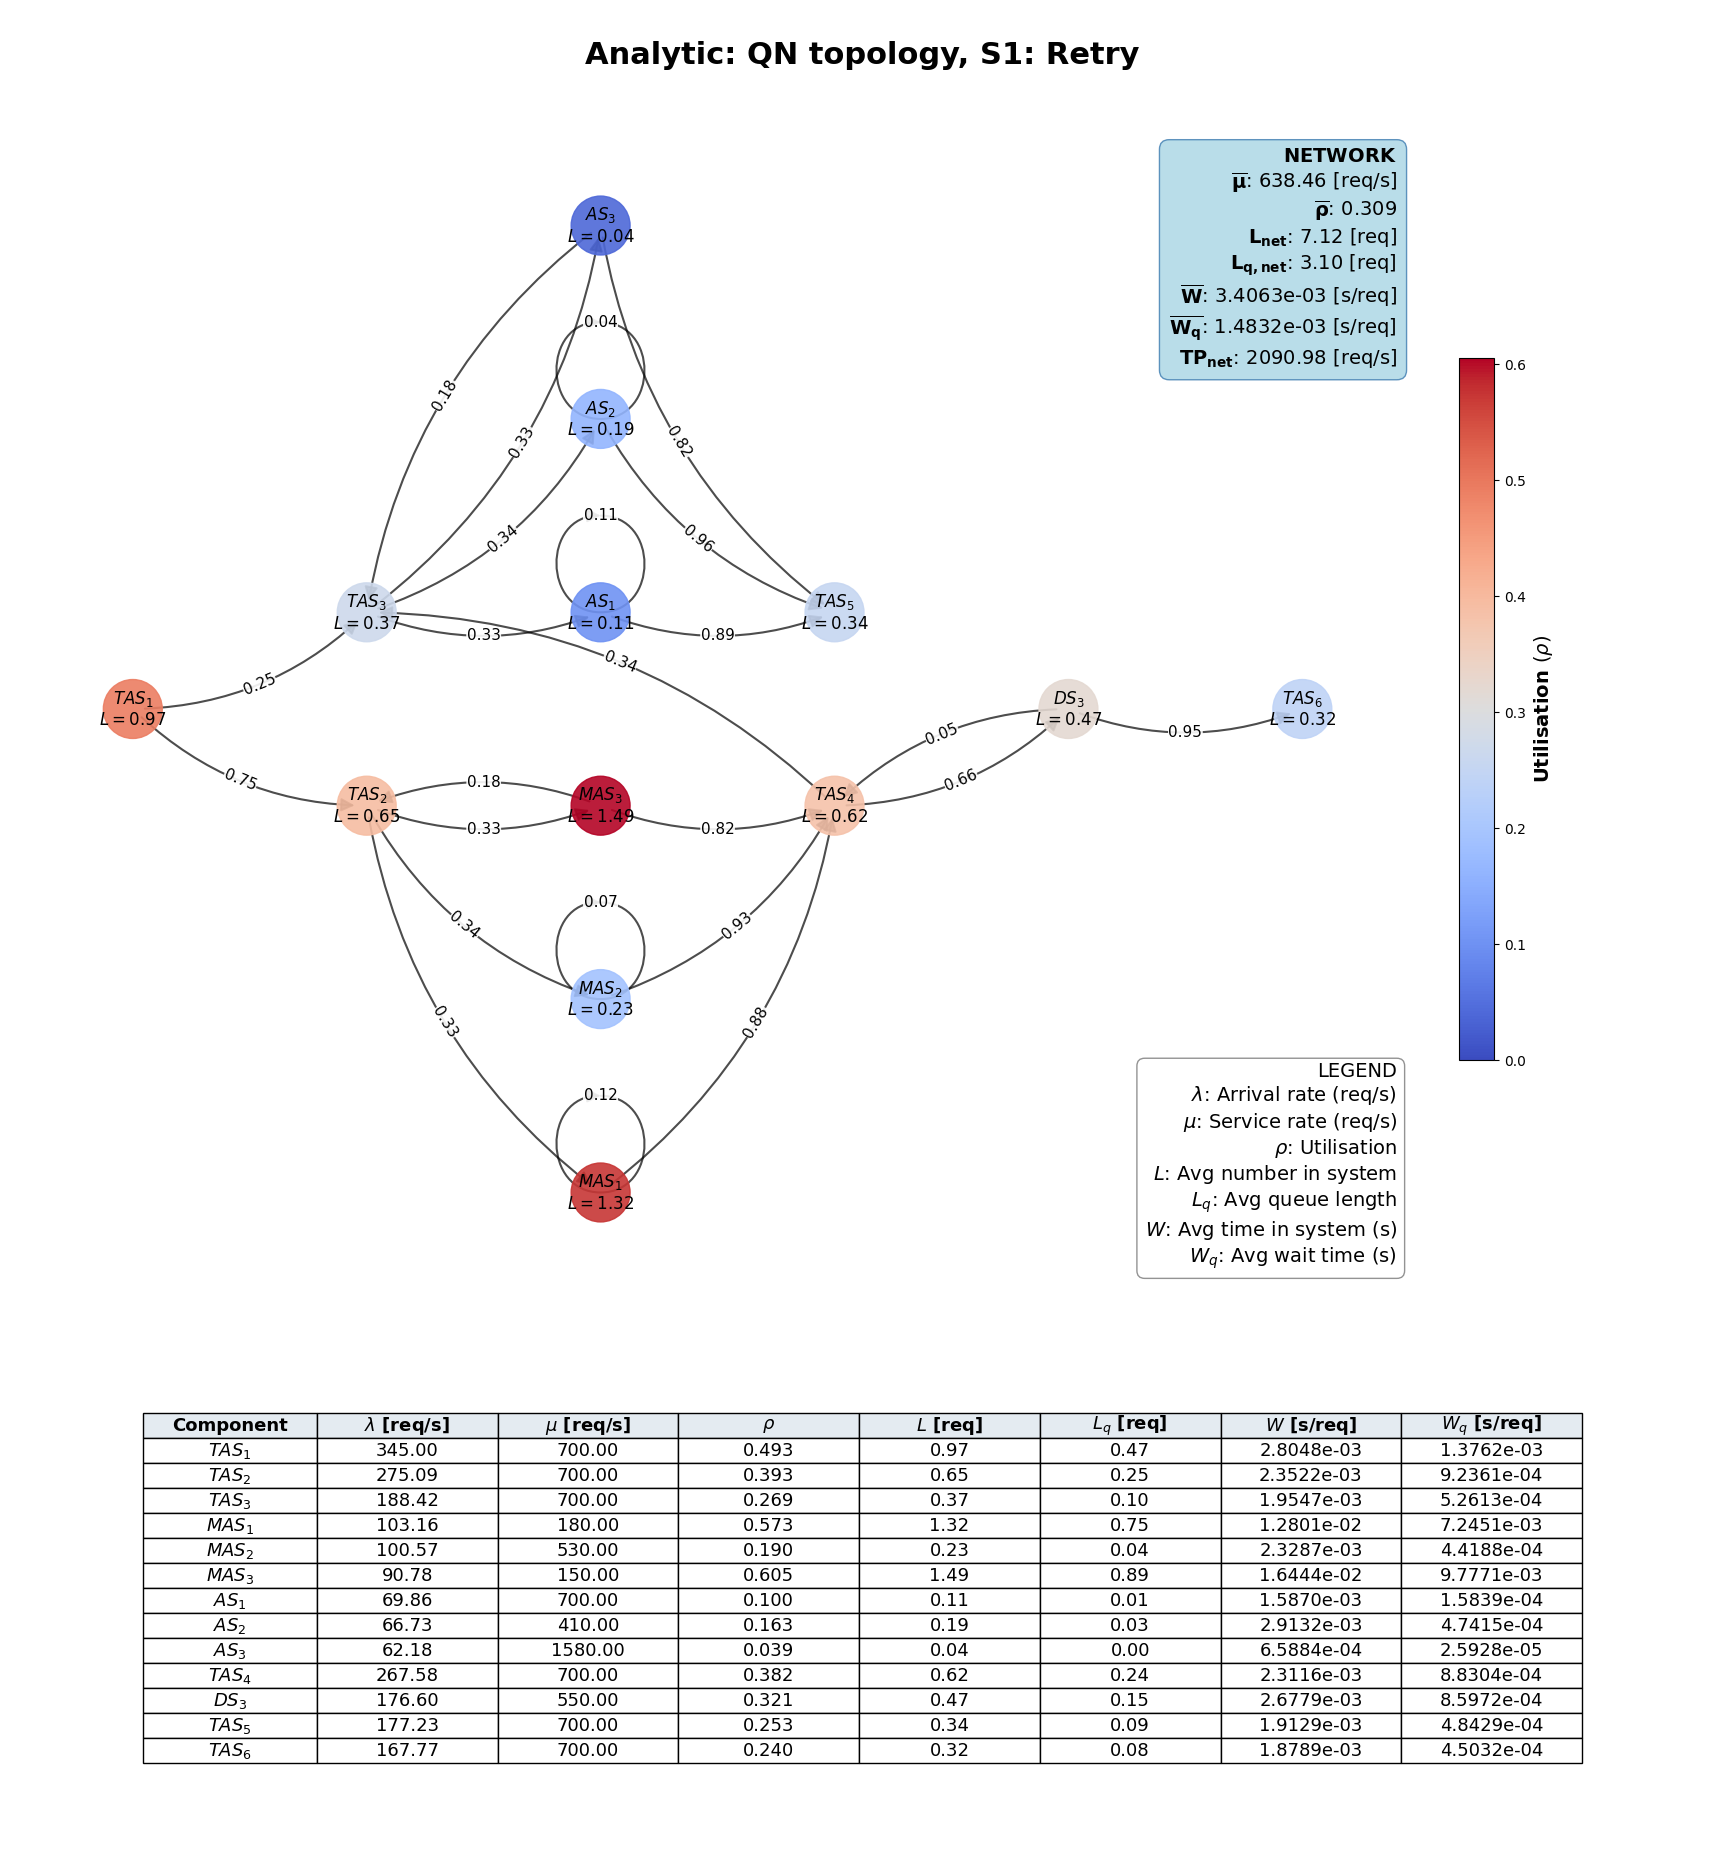

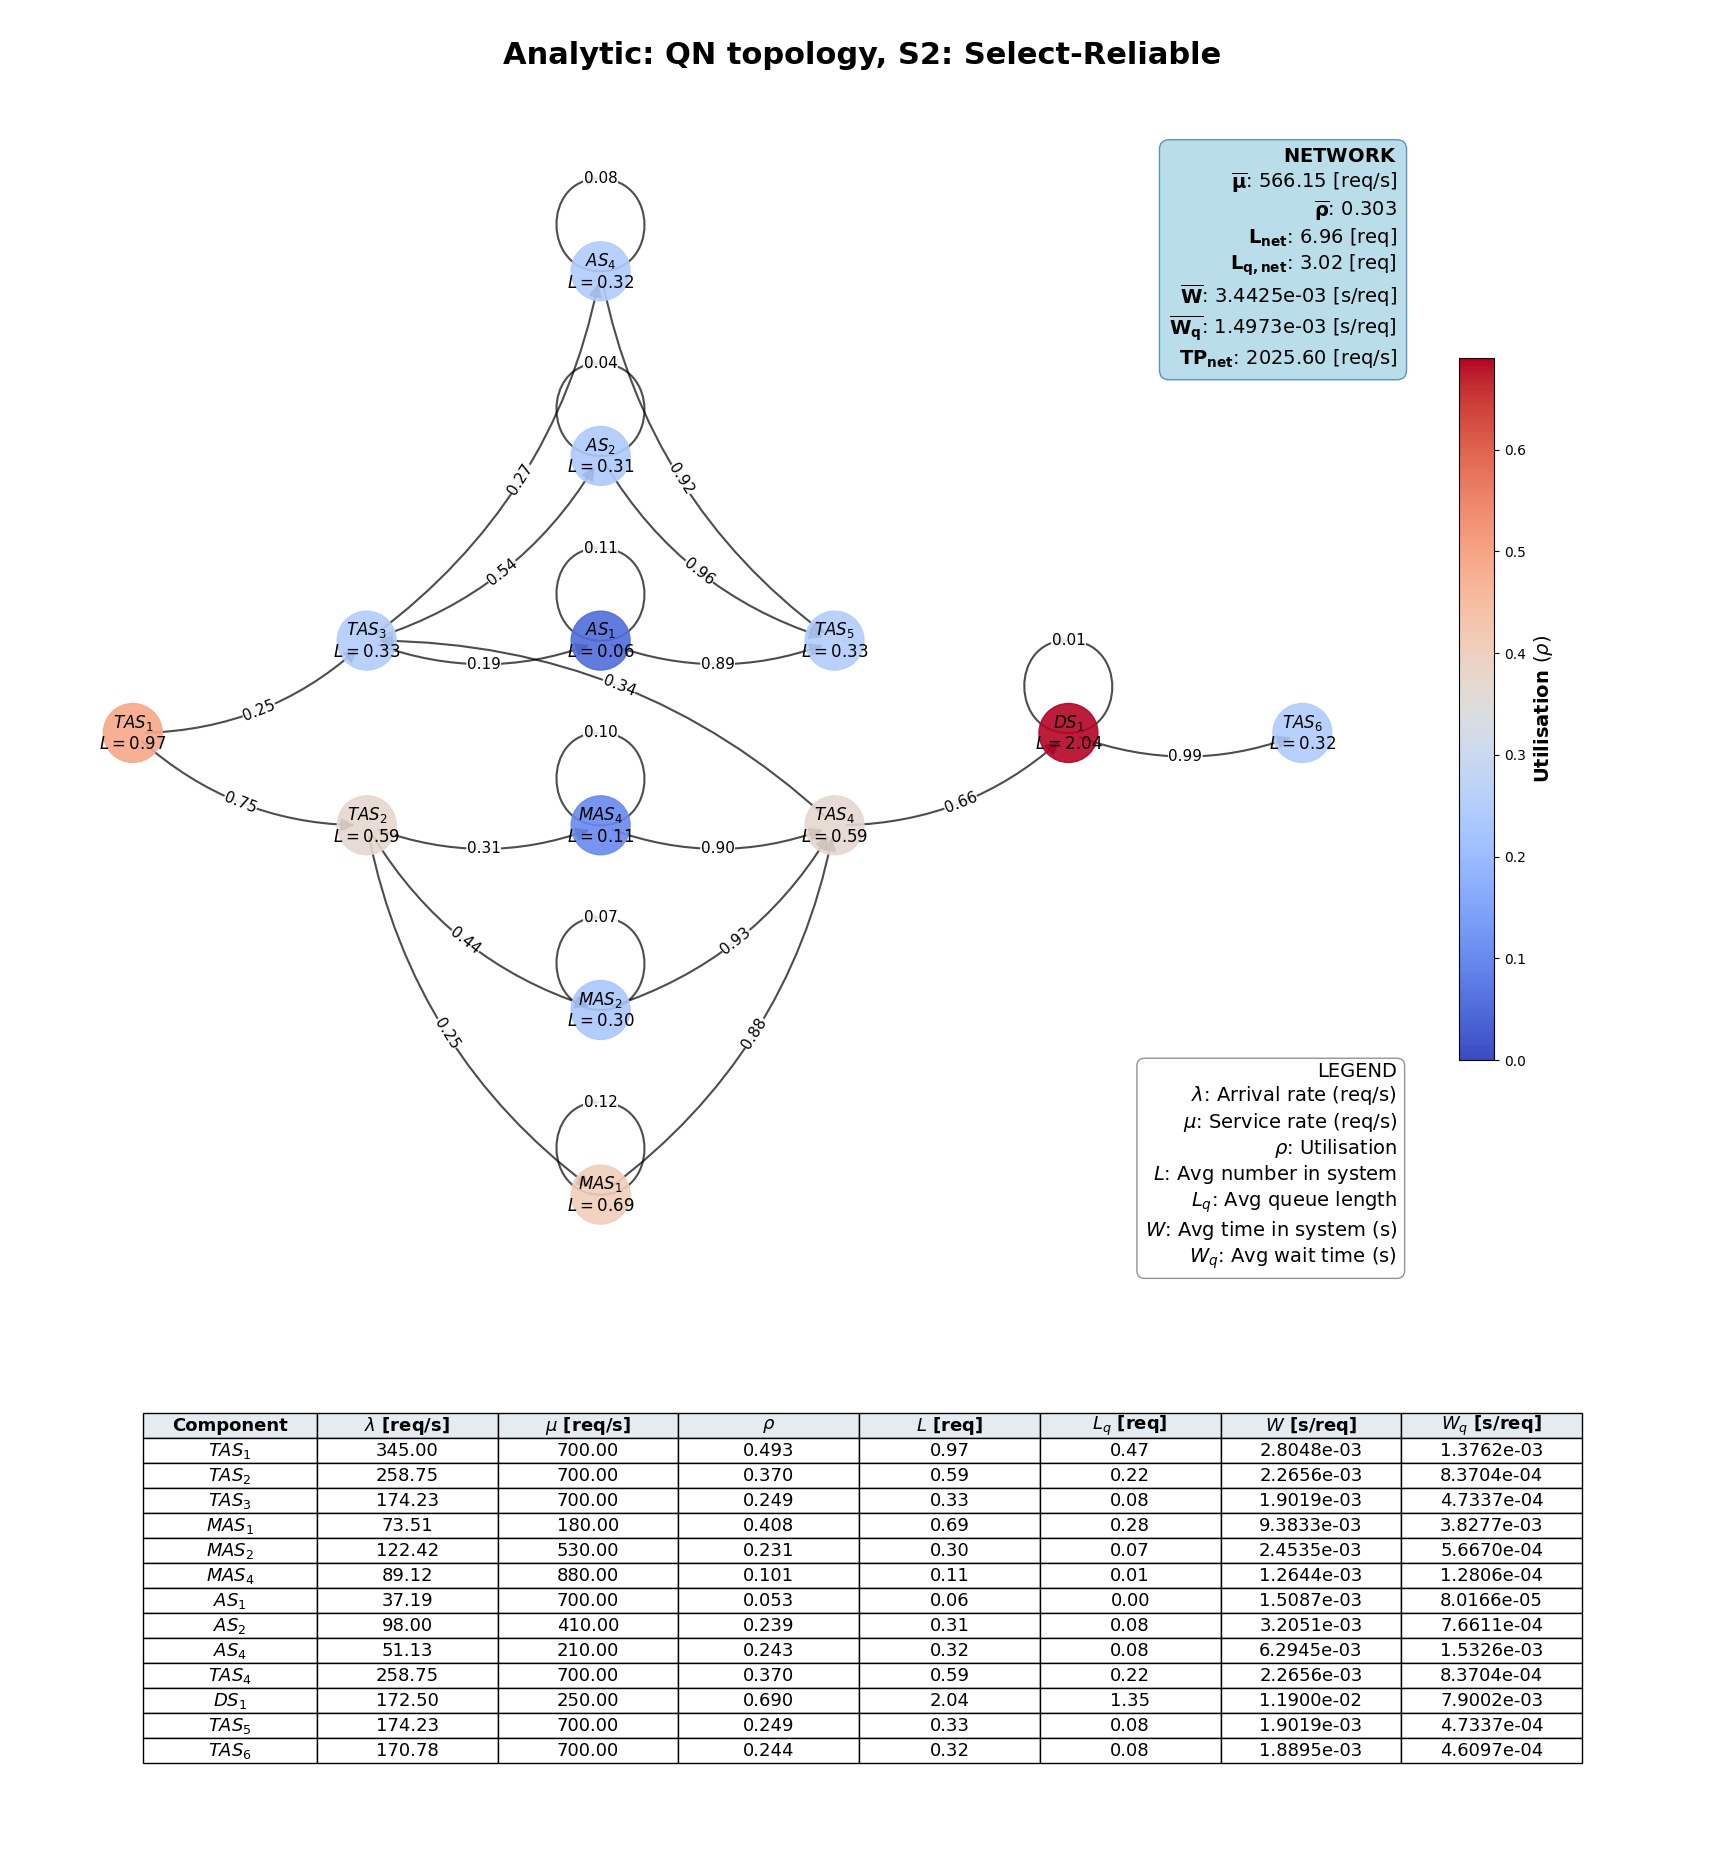

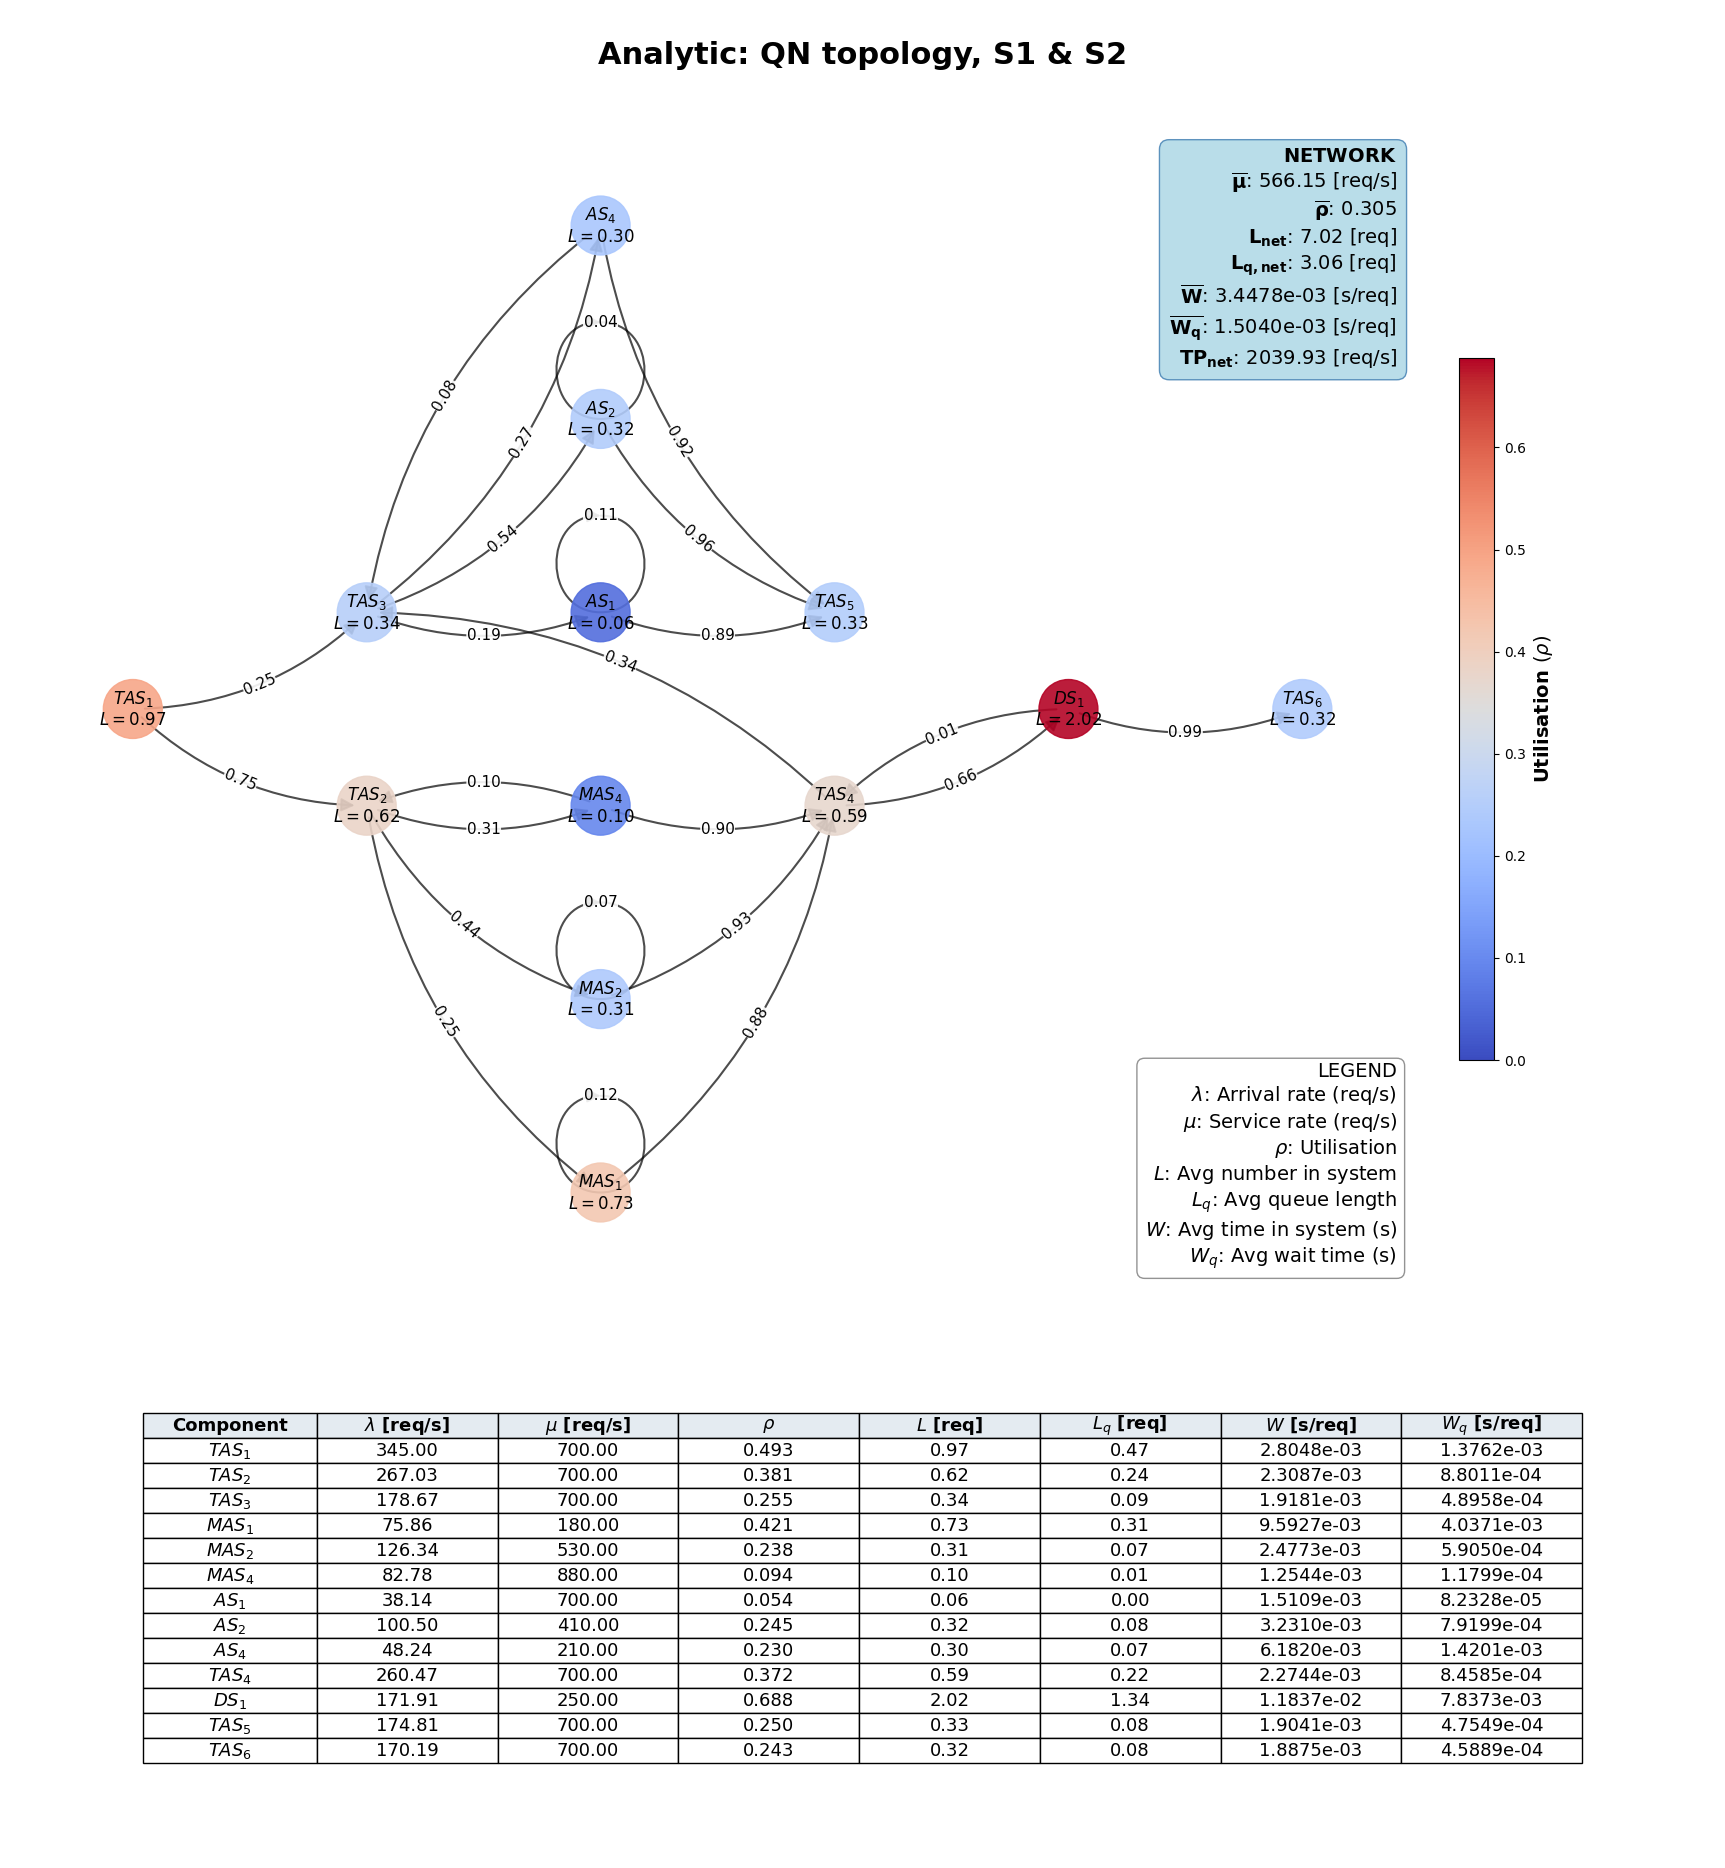

In [5]:
# standalone topology for every adaptation -> data/img/analytic/<adp>/topology.png
for a in ADAPTATIONS:
    plot_qn_topology(
        routs=cfgs[a].routing,
        ndss=nodes[a],
        nets=nets[a],
        title=f"Analytic: QN topology, {DISPLAY[a]}",
        file_path=str(IMG_ROOT / a),
        fname="topology.png")

## 5. Per-node heatmap (before vs after)

Each row = one artifact; each column = one metric. Columns are normalised per-metric across both scenarios so the heat value is directly comparable. Numeric cell labels show the raw value.

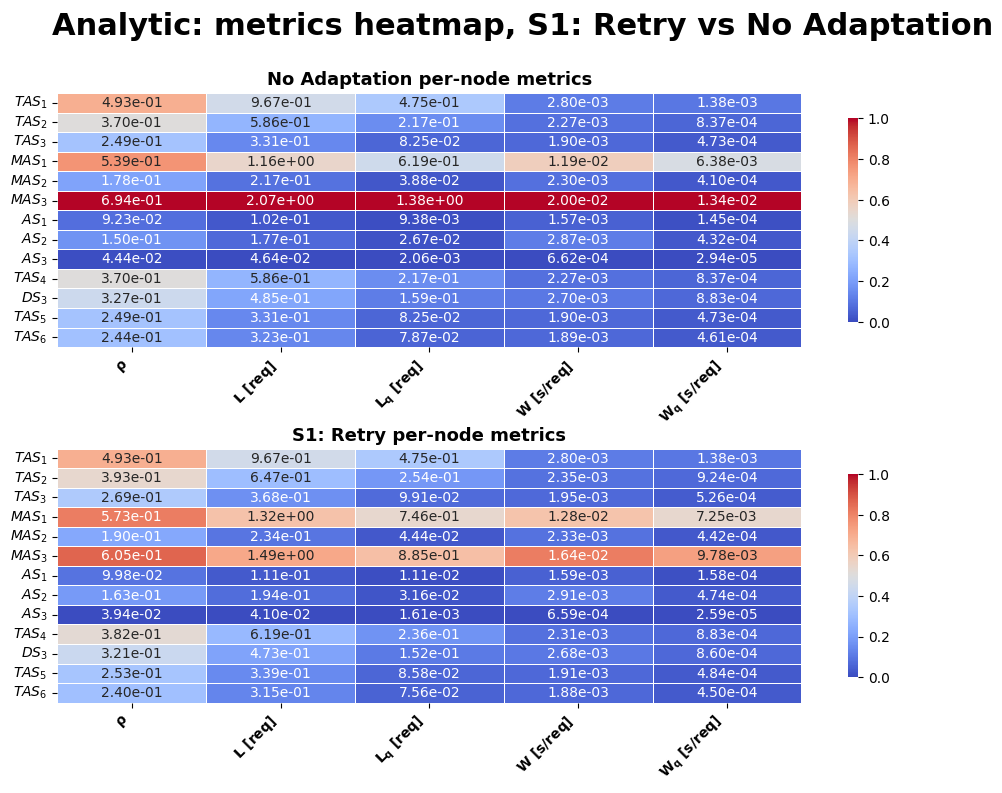

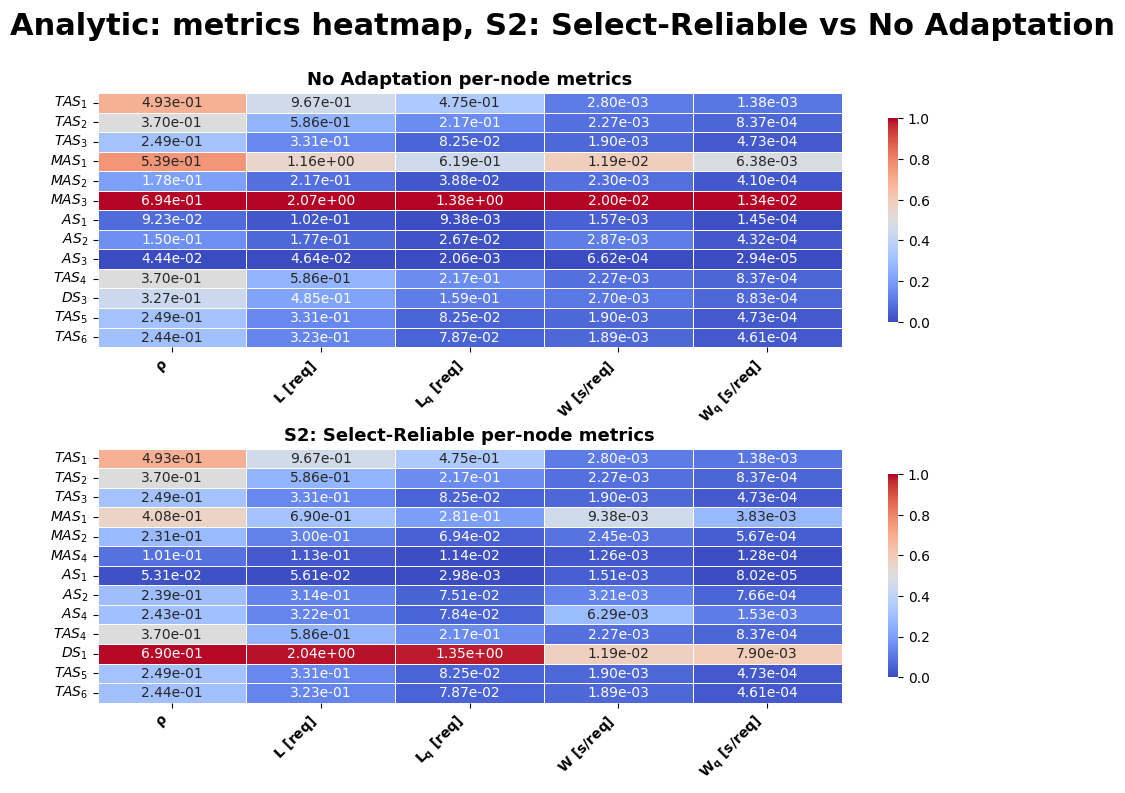

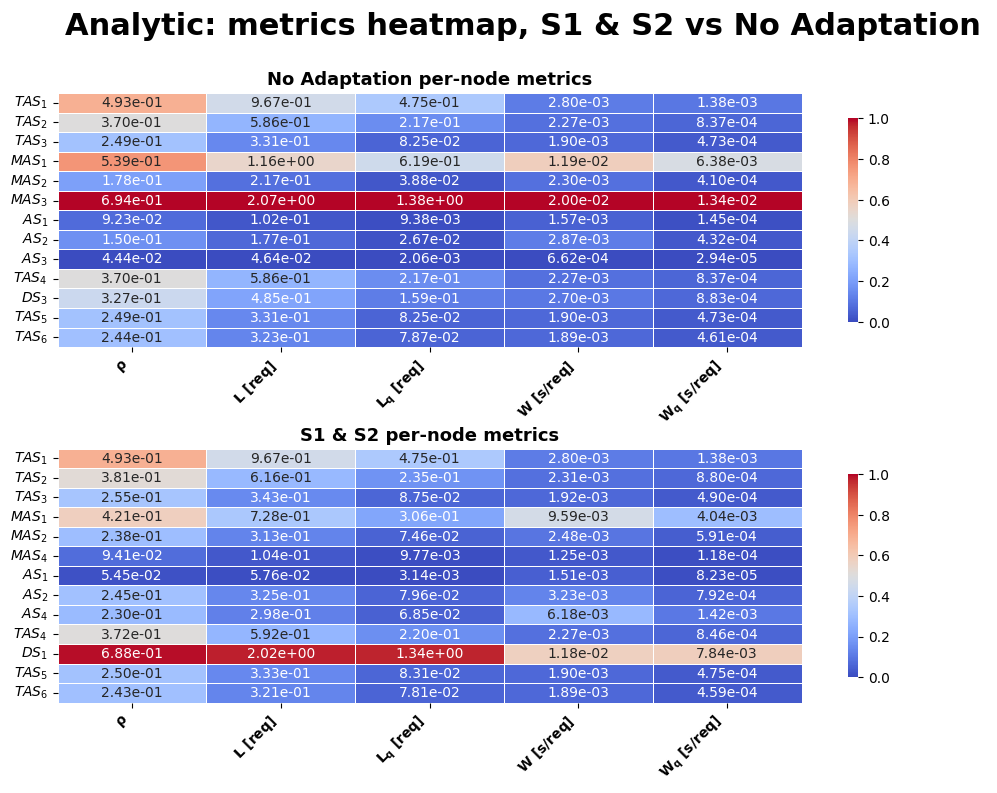

In [6]:
heat_metrics = ["rho", "L", "Lq", "W", "Wq"]
heat_labels = [
    r"$\mathbf{\rho}$",
    r"$\mathbf{L}$ [req]",
    r"$\mathbf{L_q}$ [req]",
    r"$\mathbf{W}$ [s/req]",
    r"$\mathbf{W_q}$ [s/req]",
]

# plot_node_heatmap aligns rows positionally (iloc[i]); each panel's y-axis labels come from its own `key` column, so swap-slot rows show baseline's MAS_{3}/AS_{3}/DS_{3} and s2/aggregate's MAS_{4}/AS_{4}/DS_{1} at the same row position.
for a in ["s1", "s2", "aggregate"]:
    plot_node_heatmap(
        ndss=[nodes["baseline"], nodes[a]],
        names=[DISPLAY["baseline"], DISPLAY[a]],
        metrics=heat_metrics,
        labels=heat_labels,
        title=f"Analytic: metrics heatmap, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="heatmap_vs_baseline.png")

## 5b. Per-node delta heatmap (Δ% vs baseline)

Single-panel view of the per-node, per-metric percent change between baseline and each adaptation. Centred diverging colour scale so positive and negative changes read as equal-intensity colours.

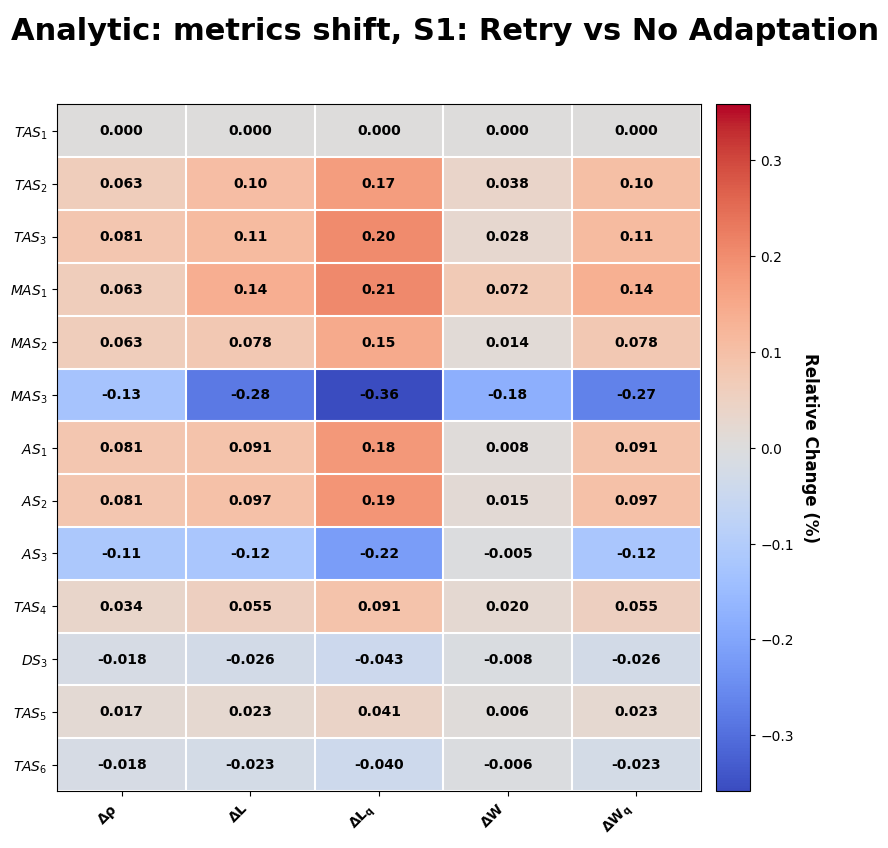

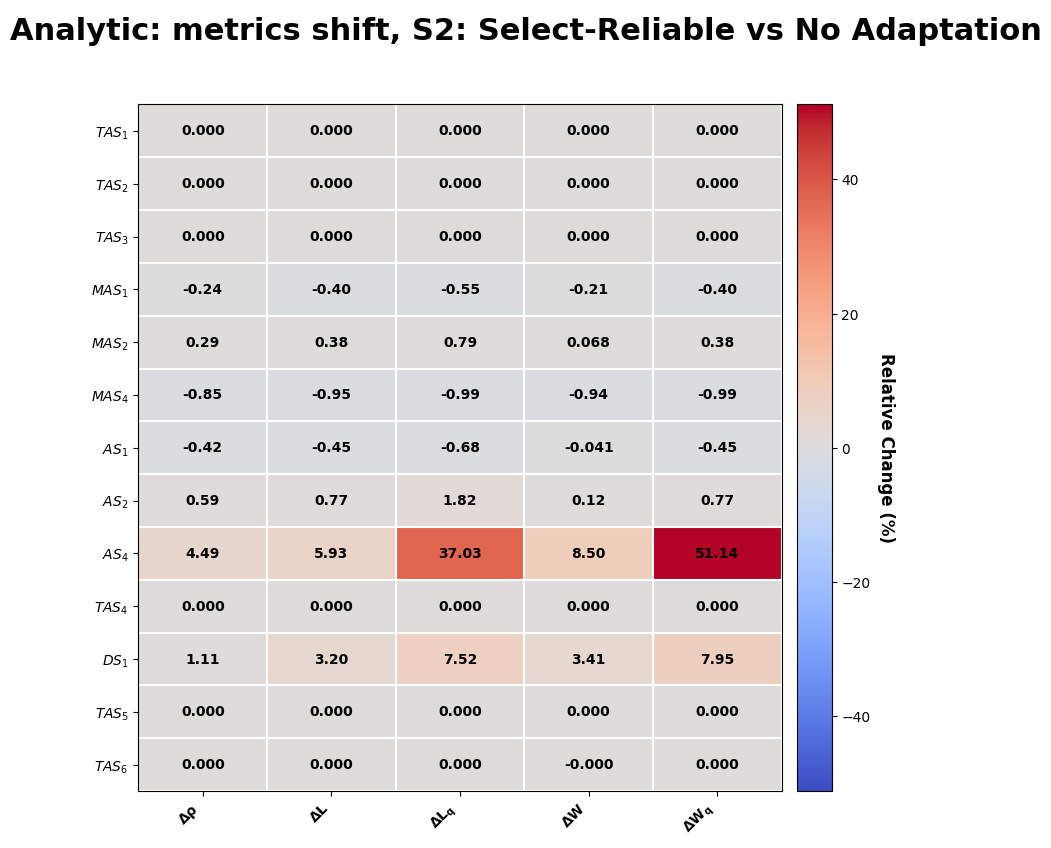

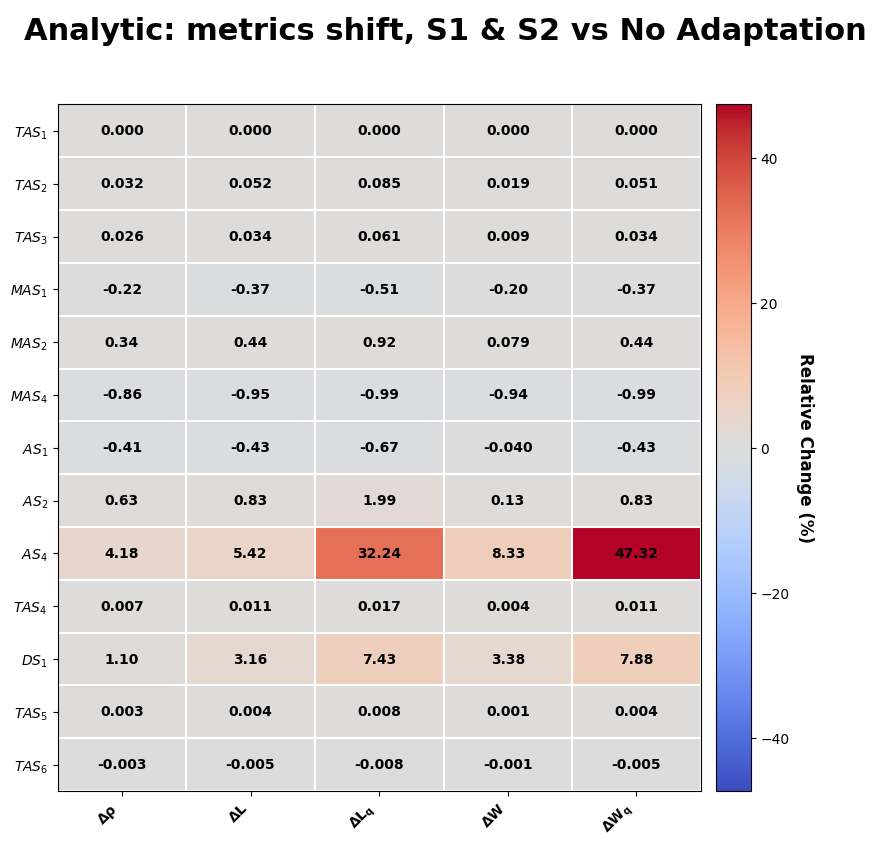

In [7]:
# single-panel delta heatmap per adaptation -> data/img/analytic/<adp>/nd_diffmap_vs_baseline.png
# Match the OLD convention: delta = (opti - dflt) / |dflt| -- ratio, not percent.
# Align by positional index (slot) since `key` may differ at swap slots (baseline MAS_{3} vs s2 MAS_{4});
# the y-axis carries each adp's actual service keys.
diff_metrics = ["rho", "L", "Lq", "W", "Wq"]
diff_labels = [
    r"$\mathbf{\Delta \rho}$",
    r"$\mathbf{\Delta L}$",
    r"$\mathbf{\Delta L_q}$",
    r"$\mathbf{\Delta W}$",
    r"$\mathbf{\Delta W_q}$",
]

bl_nodes = nodes["baseline"]
for a in ["s1", "s2", "aggregate"]:
    ac_nodes = nodes[a]
    rows = []
    for i in range(len(ac_nodes)):
        b_row = bl_nodes.iloc[i]
        c_row = ac_nodes.iloc[i]
        row = {"key": c_row["key"]}
        for m in diff_metrics:
            b, c = float(b_row[m]), float(c_row[m])
            row[m] = ((c - b) / abs(b)) if b else 0.0
        rows.append(row)
    deltas = pd.DataFrame(rows)

    plot_node_diffmap(
        deltas=deltas,
        nodes=deltas["key"].tolist(),
        metrics=diff_metrics,
        labels=diff_labels,
        title=f"Analytic: metrics shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="nd_diffmap_vs_baseline.png")

## 6. Network-wide bars (all four adaptations)

Headline comparison of the four configurations on the metrics that drive the R1 / R2 verdicts. Y-axis is log-scaled because the metrics span several orders of magnitude (W in seconds vs L in requests).

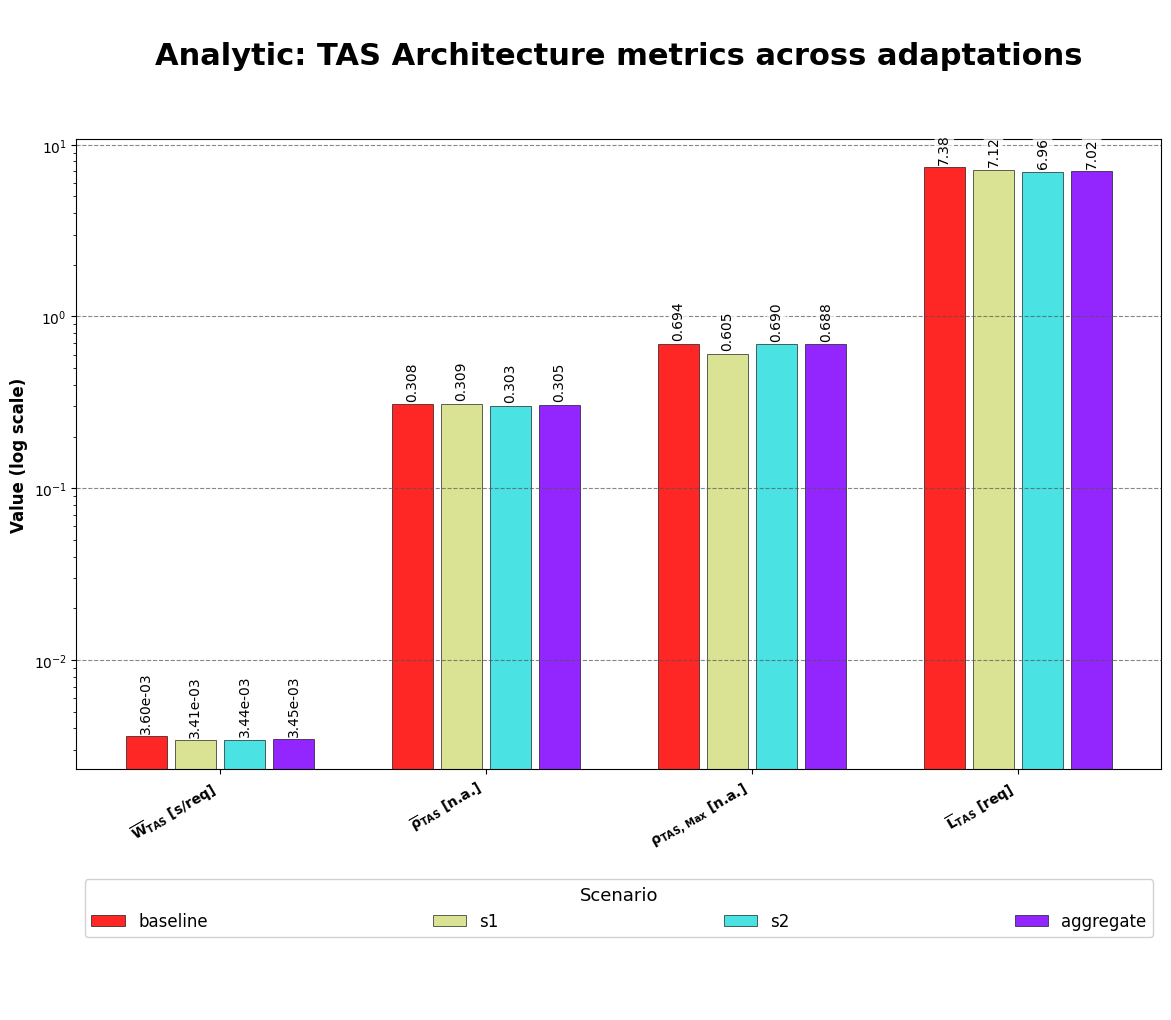

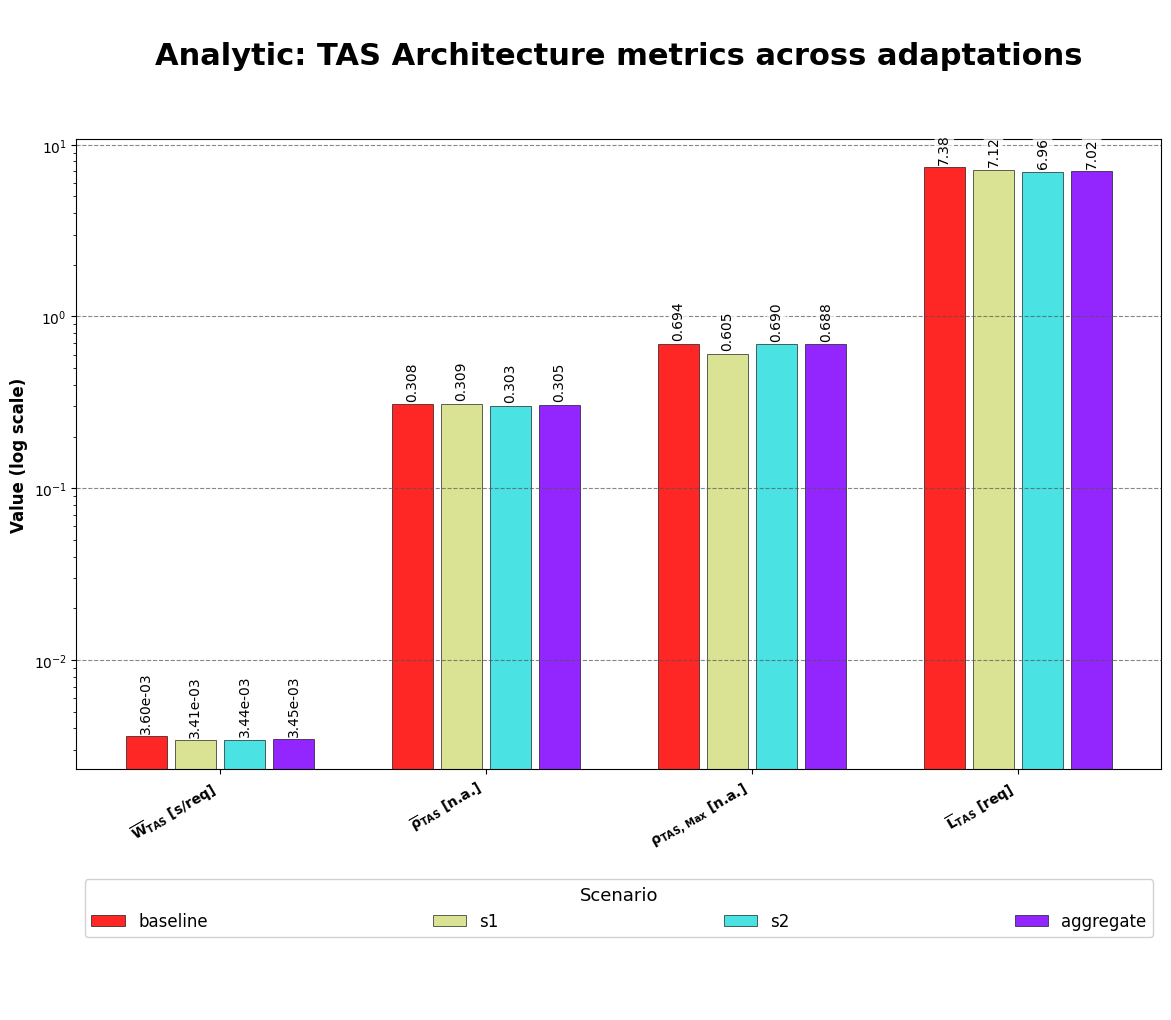

In [8]:
bar_metrics = ["W_net", "avg_rho", "max_rho", "L_net"]
bar_labels = [
    r"$\mathbf{\overline{W}_{TAS}}$ [s/req]",
    r"$\mathbf{\overline{\rho}_{TAS}}$ [n.a.]",
    r"$\mathbf{\rho_{TAS,\,Max}}$ [n.a.]",
    r"$\mathbf{\overline{L}_{TAS}}$ [req]",
]

plot_arch_bars(
    nets=[nets[a] for a in ADAPTATIONS],
    names=ADAPTATIONS,
    metrics=bar_metrics,
    labels=bar_labels,
    title="Analytic: TAS Architecture metrics across adaptations",
    file_path=str(IMG_ROOT / "aggregate"),
    fname="net_bars_all.png")

## 7. Network-wide delta (% change vs baseline)

For every non-baseline adaptation: fractional change on the headline metrics. Green bars = improvement, red = degradation. `total_throughput` flips the sign convention (more is better).

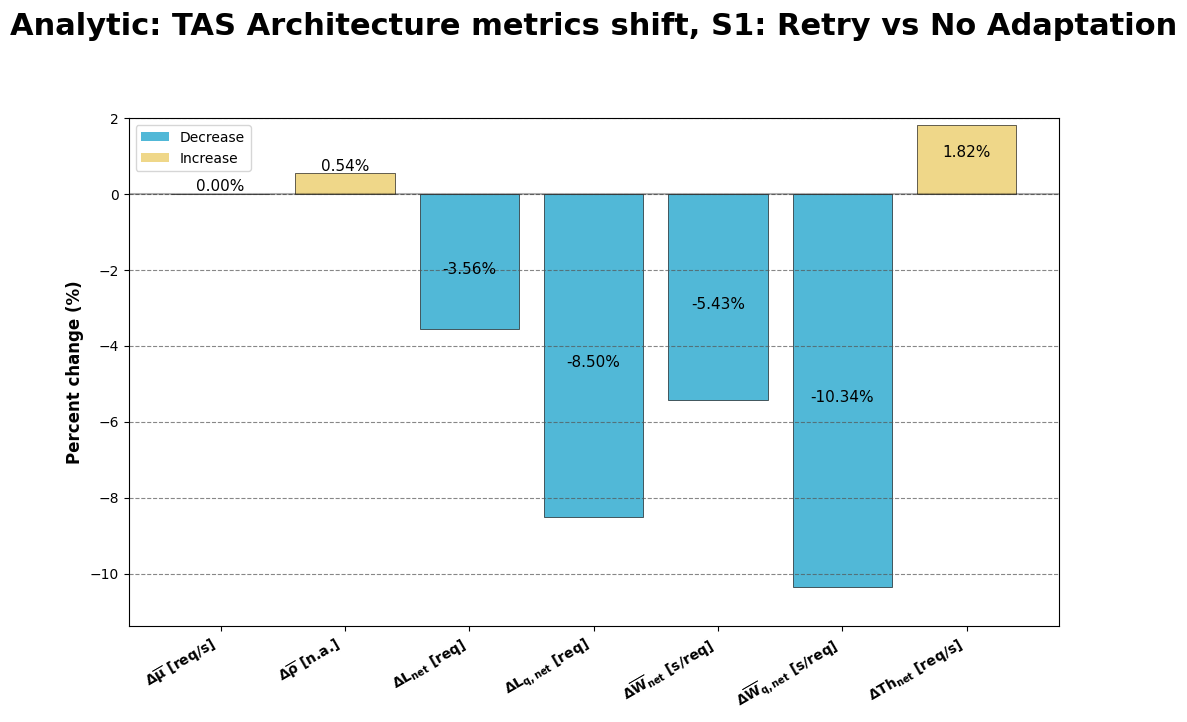

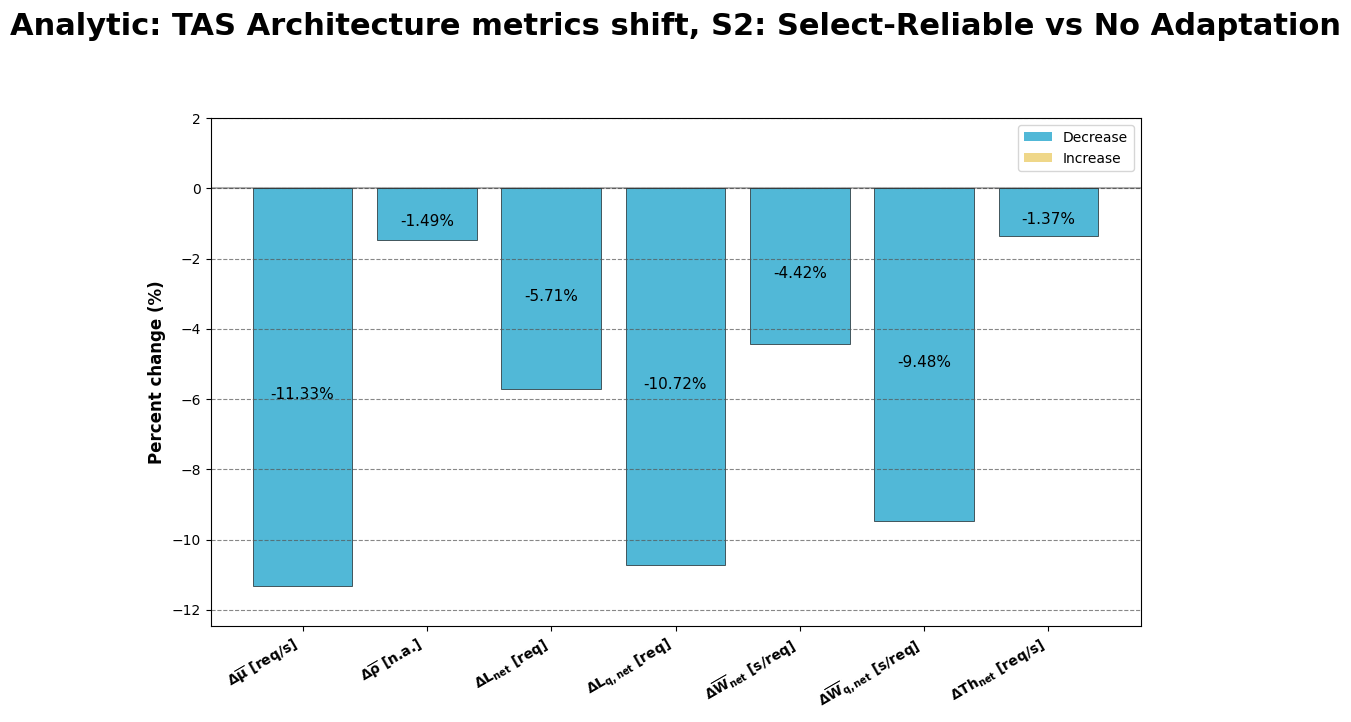

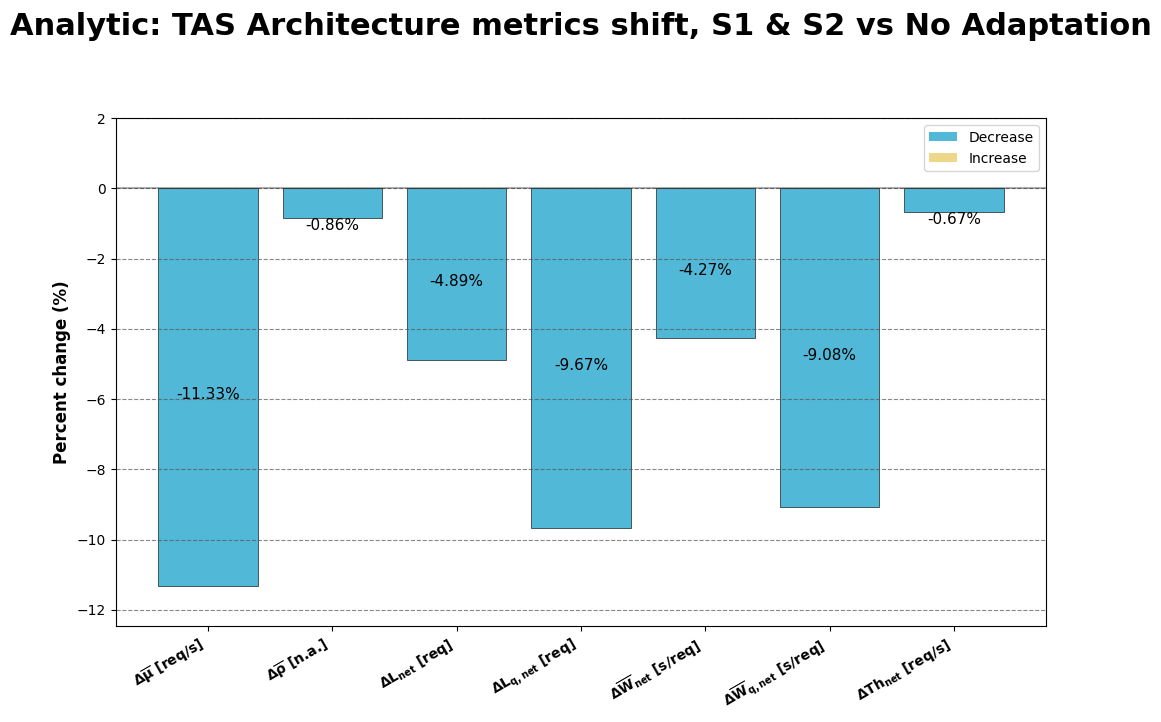

In [9]:
# fractional delta vs baseline for each non-baseline adaptation.
delta_metrics = [
    "avg_mu",
    "avg_rho",
    "L_net",
    "Lq_net",
    "W_net",
    "Wq_net",
    "total_throughput",
]

delta_labels = [
    r"$\mathbf{\Delta \overline{\mu}}$ [req/s]",
    r"$\mathbf{\Delta \overline{\rho}}$ [n.a.]",
    r"$\mathbf{\Delta L_{net}}$ [req]",
    r"$\mathbf{\Delta L_{q,net}}$ [req]",
    r"$\mathbf{\Delta \overline{W}_{net}}$ [s/req]",
    r"$\mathbf{\Delta \overline{W}_{q,net}}$ [s/req]",
    r"$\mathbf{\Delta Th_{net}}$ [req/s]",
]

bl = nets["baseline"].iloc[0]
for a in ["s1", "s2", "aggregate"]:
    ac = nets[a].iloc[0]
    row = {
        m: (ac[m] - bl[m]) / bl[m] if bl[m] else 0.0
        for m in delta_metrics
    }
    plot_arch_delta(
        deltas=pd.DataFrame([row]),
        metrics=delta_metrics,
        labels=delta_labels,
        title=f"Analytic: TAS Architecture metrics shift, {DISPLAY[a]} vs {DISPLAY['baseline']}",
        file_path=str(IMG_ROOT / a),
        fname="net_delta_vs_baseline.png")

## 8. R1 / R2 verdict table

Thresholds come from [`data/reference/baseline.json`](data/reference/baseline.json):

- **R1** Availability: `fail_rate <= 1.00 %` (fraction `0.01`)
- **R2** Performance: `resp_time <= 26 ms`

In [10]:
req_rows = []
for a in ADAPTATIONS:
    r = reqs[a]
    req_rows.append({
        "adaptation": a,
        "R1 fail_rate": r["R1"]["value"],
        "R1 pass": r["R1"]["pass"],
        "R2 resp_time (s)": r["R2"]["value"],
        "R2 pass": r["R2"]["pass"],
    })
pd.DataFrame(req_rows).set_index("adaptation")

,R1 fail_rate,R1 pass,R2 resp_time (s),R2 pass
adaptation,,,,
baseline,0.0,True,0.003602,True
s1,0.0,True,0.003406,True
s2,0.0,True,0.003443,True
aggregate,0.0,True,0.003448,True


## Summary

At the nominal 345 req/s arrival rate, all four adaptations pass R1 and R2. The aggregate configuration (opti routing + opti services) delivers the lowest `W_net` and the lowest `max_rho`; s1 alone (opti routing, dflt services at the swap slots) is the worst on `max_rho` because opti routing pushes more load into dflt services.

**Next method in the pipeline**: `stochastic.ipynb` (SimPy DES) produces the ground-truth distribution this closed-form solution is compared against.